In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
d = fetch_ucirepo(id=350)
df = d.data.features.copy()
df["default"] = d.data.targets.values.ravel()
df.to_csv("credit_default.csv", index=False)

In [ ]:
import pandas as pd
df = pd.read_csv("credit_default.csv")

In [ ]:
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   X1       30000 non-null  int64
 1   X2       30000 non-null  int64
 2   X3       30000 non-null  int64
 3   X4       30000 non-null  int64
 4   X5       30000 non-null  int64
 5   X6       30000 non-null  int64
 6   X7       30000 non-null  int64
 7   X8       30000 non-null  int64
 8   X9       30000 non-null  int64
 9   X10      30000 non-null  int64
 10  X11      30000 non-null  int64
 11  X12      30000 non-null  int64
 12  X13      30000 non-null  int64
 13  X14      30000 non-null  int64
 14  X15      30000 non-null  int64
 15  X16      30000 non-null  int64
 16  X17      30000 non-null  int64
 17  X18      30000 non-null  int64
 18  X19      30000 non-null  int64
 19  X20      30000 non-null  int64
 20  X21      30000 non-null  int64
 21  X22      30000 non-null  int64
 22  X23      30000 non-nul

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

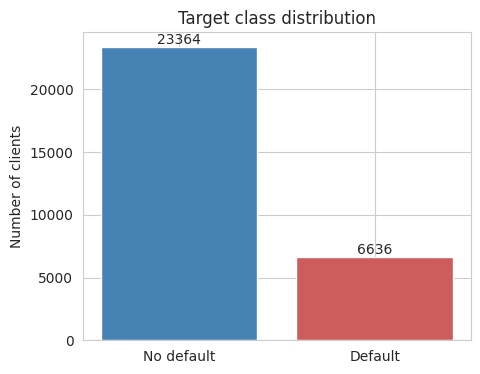

In [ ]:
plt.figure(figsize=(5, 4))
counts = df["default"].value_counts().sort_index()
plt.bar(["No default", "Default"], counts.values, color=["steelblue", "indianred"])
for i, v in enumerate(counts.values):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.ylabel("Number of clients")
plt.title("Target class distribution")
plt.show()

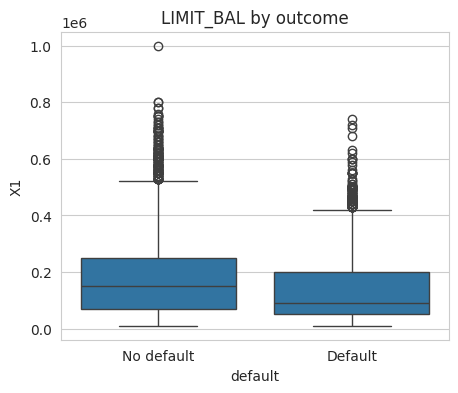

In [ ]:
plt.figure(figsize=(5, 4))
sns.boxplot(data=df, x="default", y="X1")
plt.xticks([0, 1], ["No default", "Default"])
plt.title("LIMIT_BAL by outcome")
plt.show()

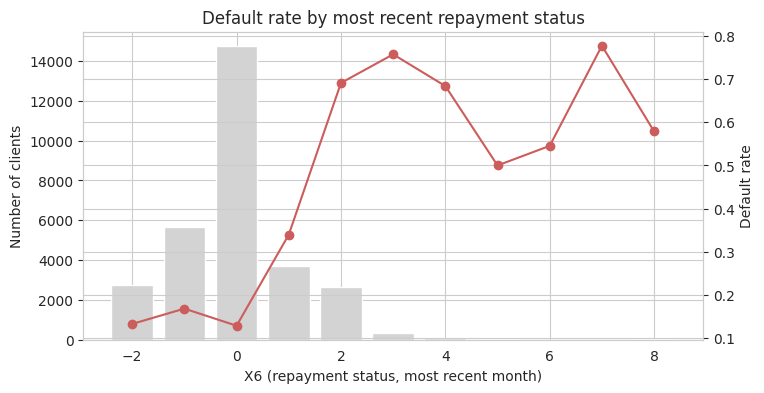

In [ ]:
default_rate = df.groupby("X6")["default"].mean()
sample_size = df.groupby("X6")["default"].size()

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(sample_size.index, sample_size.values, color="lightgray")
ax1.set_ylabel("Number of clients")
ax1.set_xlabel("X6 (repayment status, most recent month)")

ax2 = ax1.twinx()
ax2.plot(default_rate.index, default_rate.values, color="indianred", marker="o")
ax2.set_ylabel("Default rate")

plt.title("Default rate by most recent repayment status")
plt.show()

In [ ]:
new_names = {
    "X1": "LIMIT_BAL", "X2": "SEX", "X3": "EDUCATION", "X4": "MARRIAGE", "X5": "AGE",
    "X6": "PAY_0", "X7": "PAY_2", "X8": "PAY_3", "X9": "PAY_4", "X10": "PAY_5", "X11": "PAY_6",
    "X12": "BILL_AMT1", "X13": "BILL_AMT2", "X14": "BILL_AMT3",
    "X15": "BILL_AMT4", "X16": "BILL_AMT5", "X17": "BILL_AMT6",
    "X18": "PAY_AMT1", "X19": "PAY_AMT2", "X20": "PAY_AMT3",
    "X21": "PAY_AMT4", "X22": "PAY_AMT5", "X23": "PAY_AMT6",
}
df = df.rename(columns=new_names)
print(df.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']


In [ ]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   3

In [ ]:
print(df.columns.tolist())
print()
print(df["default"].value_counts())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']

default
0    23364
1     6636
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["default"])
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(24000, 23) (6000, 23)
default
0    0.778792
1    0.221208
Name: proportion, dtype: float64
default
0    0.778833
1    0.221167
Name: proportion, dtype: float64


In [ ]:
print(df["EDUCATION"].value_counts().sort_index())
print()
print(df["MARRIAGE"].value_counts().sort_index())

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["default"])
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print()
print("Train class balance:")
print(y_train.value_counts(normalize=True).sort_index())
print()
print("Test class balance:")
print(y_test.value_counts(normalize=True).sort_index())

Train shape: (24000, 23)
Test shape: (6000, 23)

Train class balance:
default
0    0.778792
1    0.221208
Name: proportion, dtype: float64

Test class balance:
default
0    0.778833
1    0.221167
Name: proportion, dtype: float64


In [ ]:
# Dummy test

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_pred = dummy.predict(X_test)
y_proba = dummy.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("AUC      :", round(roc_auc_score(y_test, y_proba), 4))
print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred, zero_division=0), 4))
print("F1       :", round(f1_score(y_test, y_pred, zero_division=0), 4))
print("MCC      :", round(matthews_corrcoef(y_test, y_pred), 4))

Accuracy : 0.7788
AUC      : 0.5
Precision: 0.0
Recall   : 0.0
F1       : 0.0
MCC      : 0.0


In [ ]:
# Trying logistic regression

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("AUC      :", round(roc_auc_score(y_test, y_proba), 4))
print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred, zero_division=0), 4))
print("F1       :", round(f1_score(y_test, y_pred, zero_division=0), 4))
print("MCC      :", round(matthews_corrcoef(y_test, y_pred), 4))

Accuracy : 0.8077
AUC      : 0.7076
Precision: 0.6868
Recall   : 0.2396
F1       : 0.3553
MCC      : 0.3244


### All models
Creating all the models in the following block and running them together in the next block for comparison. All models have same training set and the test set.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

models = {}

models["Logistic Regression"] = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])

models["Decision Tree"] = Pipeline([
    ("clf", DecisionTreeClassifier(max_depth=6, random_state=42)),
])

models["kNN"] = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=15)),
])

models["Naive Bayes"] = Pipeline([
    ("clf", GaussianNB()),
])

models["Random Forest"] = Pipeline([
    ("clf", RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)),
])

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, matthews_corrcoef

rows = []

for name in models:
    pipe = models[name]
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    rows.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "AUC": round(roc_auc_score(y_test, y_proba), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "MCC": round(matthews_corrcoef(y_test, y_pred), 4),
    })

results = pd.DataFrame(rows)
print(results.to_string(index=False))

              Model  Accuracy    AUC  Precision  Recall     F1    MCC
Logistic Regression    0.8077 0.7076     0.6868  0.2396 0.3553 0.3244
      Decision Tree    0.8163 0.7450     0.6543  0.3595 0.4640 0.3881
                kNN    0.8065 0.7326     0.6153  0.3338 0.4328 0.3507
        Naive Bayes    0.4160 0.6516     0.2496  0.8176 0.3824 0.1111
      Random Forest    0.8170 0.7728     0.6615  0.3534 0.4607 0.3884


In [ ]:
print(results.to_markdown(index=False))

| Model               |   Accuracy |    AUC |   Precision |   Recall |     F1 |    MCC |
|:--------------------|-----------:|-------:|------------:|---------:|-------:|-------:|
| Logistic Regression |     0.8077 | 0.7076 |      0.6868 |   0.2396 | 0.3553 | 0.3244 |
| Decision Tree       |     0.8163 | 0.745  |      0.6543 |   0.3595 | 0.464  | 0.3881 |
| kNN                 |     0.8065 | 0.7326 |      0.6153 |   0.3338 | 0.4328 | 0.3507 |
| Naive Bayes         |     0.416  | 0.6516 |      0.2496 |   0.8176 | 0.3824 | 0.1111 |
| Random Forest       |     0.817  | 0.7728 |      0.6615 |   0.3534 | 0.4607 | 0.3884 |


### Saving pipelines

In [ ]:
import os
import joblib

os.makedirs("model", exist_ok=True)

filenames = {
    "Logistic Regression": "logistic_regression",
    "Decision Tree": "decision_tree",
    "kNN": "knn",
    "Naive Bayes": "naive_bayes",
    "Random Forest": "random_forest",
}

for name in models:
    path = "model/" + filenames[name] + ".joblib"
    joblib.dump(models[name], path)
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(path, round(size_mb, 2), "MB")

model/logistic_regression.joblib 0.0 MB
model/decision_tree.joblib 0.01 MB
model/knn.joblib 4.4 MB
model/naive_bayes.joblib 0.0 MB
model/random_forest.joblib 11.19 MB


### Saving test data

In [ ]:
test_df = X_test.copy()
test_df["default"] = y_test
test_df.to_csv("test_data.csv", index=False)
print(test_df.shape)

(6000, 24)


### Gather versions

In [ ]:
import sklearn, pandas, numpy, joblib
print("scikit-learn", sklearn.__version__)
print("pandas", pandas.__version__)
print("numpy", numpy.__version__)
print("joblib", joblib.__version__)

scikit-learn 1.6.1
pandas 2.2.2
numpy 2.0.2
joblib 1.5.3
